<a href="https://colab.research.google.com/github/mikhael2104/visi_komputer/blob/main/Jobsheet_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **JOBSHEET 02: KLASIFIKASI GAMBAR**

### **PRAKTIKUM SECTION**

PRAKTIKUM 1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

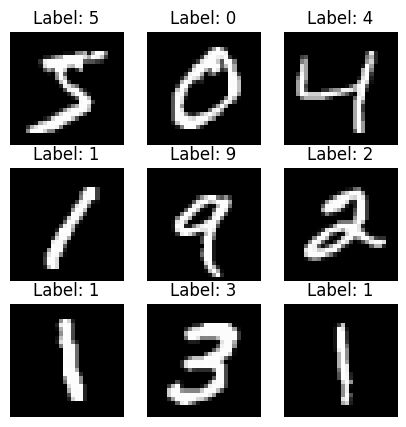

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

#Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

PRAKTIKUM 2 - Klasifikasi Gambar dengan Model Machine Learning Tradisional

In [9]:
from sklearn import svm
from sklearn.metrics import accuracy_score

#Flatten
x_train_flat = x_train.reshape(len(x_train), -1)/255.0
x_test_flat = x_test.reshape(len(x_test), -1)/255.0

#SVM
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000])
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9101


PRAKTIKUM 3 - Membangun CNN Sederhana

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.9370 - loss: 0.2163 - val_accuracy: 0.9757 - val_loss: 0.0828
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.9794 - loss: 0.0696 - val_accuracy: 0.9863 - val_loss: 0.0531
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.9851 - loss: 0.0474 - val_accuracy: 0.9825 - val_loss: 0.0606
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9897 - loss: 0.0342 - val_accuracy: 0.9852 - val_loss: 0.0522
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9920 - loss: 0.0257 - val_accuracy: 0.9863 - val_loss: 0.0486


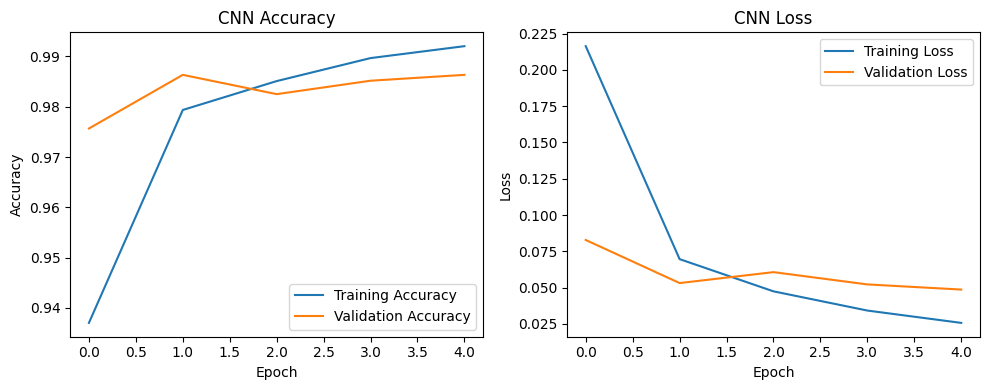

In [10]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Reshape data ke format (batch, height, width, channels)
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Bangun arsitektur CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

# 3. Kompilasi dan pelatihan
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x_train_cnn, y_train, epochs=5, validation_split=0.1, batch_size=64
)

# 4. Plot riwayat pelatihan
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

PRAKTIKUM 4 - Eksperimen dengan Dataset lebih Kompleks

In [ ]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

#===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2504s 15us/step
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 40ms/step - accuracy: 0.4724 - loss: 1.4657 - val_accuracy: 0.5944 - val_loss: 1.1595
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.6080 - loss: 1.1171 - val_accuracy: 0.6382 - val_loss: 1.0370
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - accuracy: 0.6504 - loss: 0.9932 - val_accuracy: 0.6604 - val_loss: 0.9729
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 37ms/step - accuracy: 0.6816 - loss: 0.9054 - val_accuracy: 0.6802 - val_loss: 0.9294
Epoch 5/10
 652/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.7148 - loss: 0.8251

PRAKTIKUM 5 - Transfer Learning dengan Model Pra-Latih

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

# 1. Muat backbone pre-trained ImageNet tanpa classifier bawaan
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# 2. Susun arsitektur Transfer Learning
model_tl = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model_tl.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_tl = model_tl.fit(
    x_train_c10,
    y_train_c10,
    epochs=5,
    validation_split=0.1,
    batch_size=64,
)

# 3. Plot hasil evaluasi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history["accuracy"], label="Training Accuracy")
plt.plot(history_tl.history["val_accuracy"], label="Validation Accuracy")
plt.title("Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tl.history["loss"], label="Training Loss")
plt.plot(history_tl.history["val_loss"], label="Validation Loss")
plt.title("Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

PRAKTIKUM 6 - Evaluasi dengan Confusion Matrix dan Metrik Lain

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Inferensi label prediksi pada data test CIFAR-10
y_pred_probs = model_c10.predict(x_test_c10)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_c10.flatten()

# 2. Classification Report
cifar10_classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]
print(
    classification_report(y_true, y_pred, target_names=cifar10_classes)
)  #

# 3. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cifar10_classes,
    yticklabels=cifar10_classes,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix CIFAR-10")
plt.show()

### **PENUGASAN SECTION**